# 🧹 Complete Data Cleaning, Preprocessing & Preparation
### Every Technique You'll Ever Need | From Raw Data to Model-Ready

---
**Sections:**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Missing Value Handling
4. Duplicate Detection & Removal
5. Outlier Detection & Treatment
6. Data Type Conversion
7. String & Text Cleaning
8. Feature Engineering
9. Encoding Categorical Variables
10. Feature Scaling & Normalization
11. Handling Imbalanced Data
12. Feature Selection
13. Dimensionality Reduction
14. Date & Time Processing
15. Pipelines & Final Preparation
---

## 1. 📦 Setup & Imports

In [3]:
#  Core Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Scikit-learn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    Normalizer, PowerTransformer, QuantileTransformer,
    LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sklearn.feature_selection import (
    SelectKBest, SelectPercentile, VarianceThreshold,
    f_classif, f_regression, mutual_info_classif,
    RFE, RFECV, SelectFromModel
)
from sklearn.decomposition import PCA, TruncatedSVD, FastICA, NMF
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM

#  Imbalanced Data 
try:
    from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler, SVMSMOTE
    from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
    from imblearn.combine import SMOTETomek, SMOTEENN
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN = True
    print(' imbalanced-learn available')
except ImportError:
    IMBLEARN = False
    print('  imbalanced-learn not installed: pip install imbalanced-learn')

#  Visualization 
try:
    import missingno as msno
    MSNO = True
    print(' missingno available')
except ImportError:
    MSNO = False

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42


 imbalanced-learn available
 missingno available


## 2. 🗂️ Create Synthetic Messy Dataset

In [4]:
np.random.seed(RANDOM_STATE)
n = 1000

df_raw = pd.DataFrame({
    # Numeric features
    'age':          np.random.randint(18, 80, n).astype(float),
    'income':       np.random.exponential(50000, n),
    'score':        np.random.normal(70, 15, n),
    'balance':      np.random.normal(5000, 2000, n),
    'transactions': np.random.poisson(20, n).astype(float),
    # Categorical features
    'gender':       np.random.choice(['Male','Female','male','FEMALE', None, 'M', 'F'], n),
    'city':         np.random.choice(['Cairo','Alex','Giza','Luxor','Aswan', None], n),
    'product':      np.random.choice(['A','B','C','D'], n, p=[0.5,0.3,0.15,0.05]),
    'education':    np.random.choice(['High School','Bachelor','Master','PhD', None], n),
    # Date feature
    'signup_date':  pd.to_datetime('2020-01-01') + pd.to_timedelta(np.random.randint(0,1460,n), unit='D'),
    # Target
    'churn':        np.random.choice([0, 1], n, p=[0.85, 0.15])
})

# Inject missing values
for col in ['age','income','score','balance','transactions']:
    idx = np.random.choice(n, size=int(n*0.08), replace=False)
    df_raw.loc[idx, col] = np.nan

# Inject outliers
df_raw.loc[np.random.choice(n,10), 'income'] = np.random.uniform(500000, 2000000, 10)
df_raw.loc[np.random.choice(n,5),  'age']    = np.random.choice([-5, 150, 999], 5)

# Inject duplicates
duplicates = df_raw.sample(30, random_state=1)
df_raw = pd.concat([df_raw, duplicates], ignore_index=True)

# String column with issues
df_raw['name'] = ['User_' + str(i) + np.random.choice(['', '  ', '!']) for i in range(len(df_raw))]
df_raw['email'] = np.random.choice(['user@mail.com','ADMIN@MAIL.COM', 'bad-email', None, ' '], len(df_raw))

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (1030, 13)


,age,income,score,balance,transactions,gender,city,product,education,signup_date,churn,name,email
0,56.0000,23639.4930,NaN,6070.2829,17.0000,Female,Cairo,A,Bachelor,2022-02-25,0,User_0,bad-email
1,69.0000,69230.4491,62.7693,6518.7759,13.0000,F,Aswan,A,High School,2022-06-28,0,User_1,user@mail.com
2,46.0000,24960.4553,49.0372,7722.4202,20.0000,F,Alex,A,Bachelor,2022-09-08,0,User_2,user@mail.com
3,32.0000,88352.6269,68.5713,3010.0002,20.0000,FEMALE,Giza,A,None,2023-09-22,1,User_3,user@mail.com
4,60.0000,42091.8115,75.8560,6051.9551,15.0000,Male,Giza,A,None,2021-01-13,0,User_4,user@mail.com


## 3. 🔍 Exploratory Data Analysis (EDA)

In [5]:
print('='*60)
print('SHAPE:', df_raw.shape)
print('='*60)
print('\n--- Data Types ---')
print(df_raw.dtypes)
print('\n--- Basic Statistics ---')
df_raw.describe(include='all').T

SHAPE: (1030, 13)

--- Data Types ---
age                    float64
income                 float64
score                  float64
balance                float64
transactions           float64
gender                  object
city                    object
product                 object
education               object
signup_date     datetime64[ns]
churn                    int64
name                    object
email                   object
dtype: object

--- Basic Statistics ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
age,947.0000,NaN,NaN,NaN,51.8163,-5.0000,35.0000,50.0000,66.0000,999.0000,47.3771
income,949.0000,NaN,NaN,NaN,65645.8598,11.8776,16235.6773,38289.8435,71155.3547,1948187.2677,154197.9505
score,947.0000,NaN,NaN,NaN,70.5043,19.1736,60.3125,70.9839,81.0090,118.8197,15.3504
balance,948.0000,NaN,NaN,NaN,5065.0008,-906.1502,3687.1935,5108.7562,6414.5784,11520.9822,2053.0216
transactions,950.0000,NaN,NaN,NaN,19.8642,8.0000,17.0000,20.0000,23.0000,43.0000,4.4617
gender,898,6,Male,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,877,5,Cairo,204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,1030,4,A,559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,804,4,PhD,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,1030,NaN,NaN,NaN,2022-01-11 16:07:27.378640640,2020-01-01 00:00:00,2021-01-03 06:00:00,2022-01-26 12:00:00,2023-01-10 12:00:00,2023-12-30 00:00:00,NaN


Missing Value Report:


,Missing,Pct%,DType
education,226,21.9417,object
email,200,19.4175,object
city,153,14.8544,object
gender,132,12.8155,object
age,83,8.0583,float64
score,83,8.0583,float64
balance,82,7.9612,float64
income,81,7.8641,float64
transactions,80,7.7670,float64


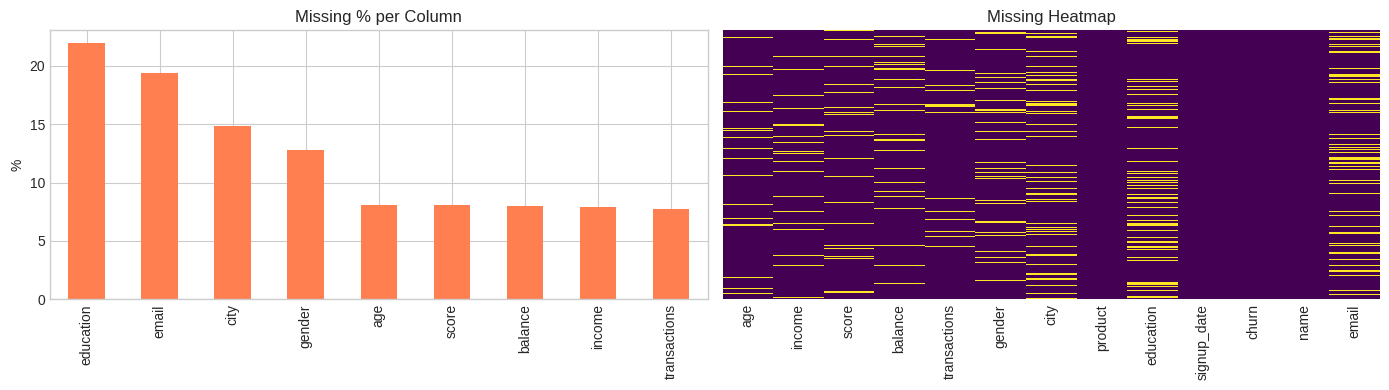

In [6]:
# Missing Value Summary
def missing_summary(df):
    miss = df.isnull().sum()
    pct  = 100 * miss / len(df)
    tbl  = pd.DataFrame({'Missing':miss,'Pct%':pct,'DType':df.dtypes})
    return tbl[tbl['Missing']>0].sort_values('Pct%', ascending=False)

print('Missing Value Report:')
display(missing_summary(df_raw))

fig, axes = plt.subplots(1,2, figsize=(14,4))
miss_pct = (df_raw.isnull().sum()/len(df_raw)*100).sort_values(ascending=False)
miss_pct[miss_pct>0].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Missing % per Column'); axes[0].set_ylabel('%')
axes[1].set_title('Missing Heatmap')
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[1])
plt.tight_layout(); plt.show()

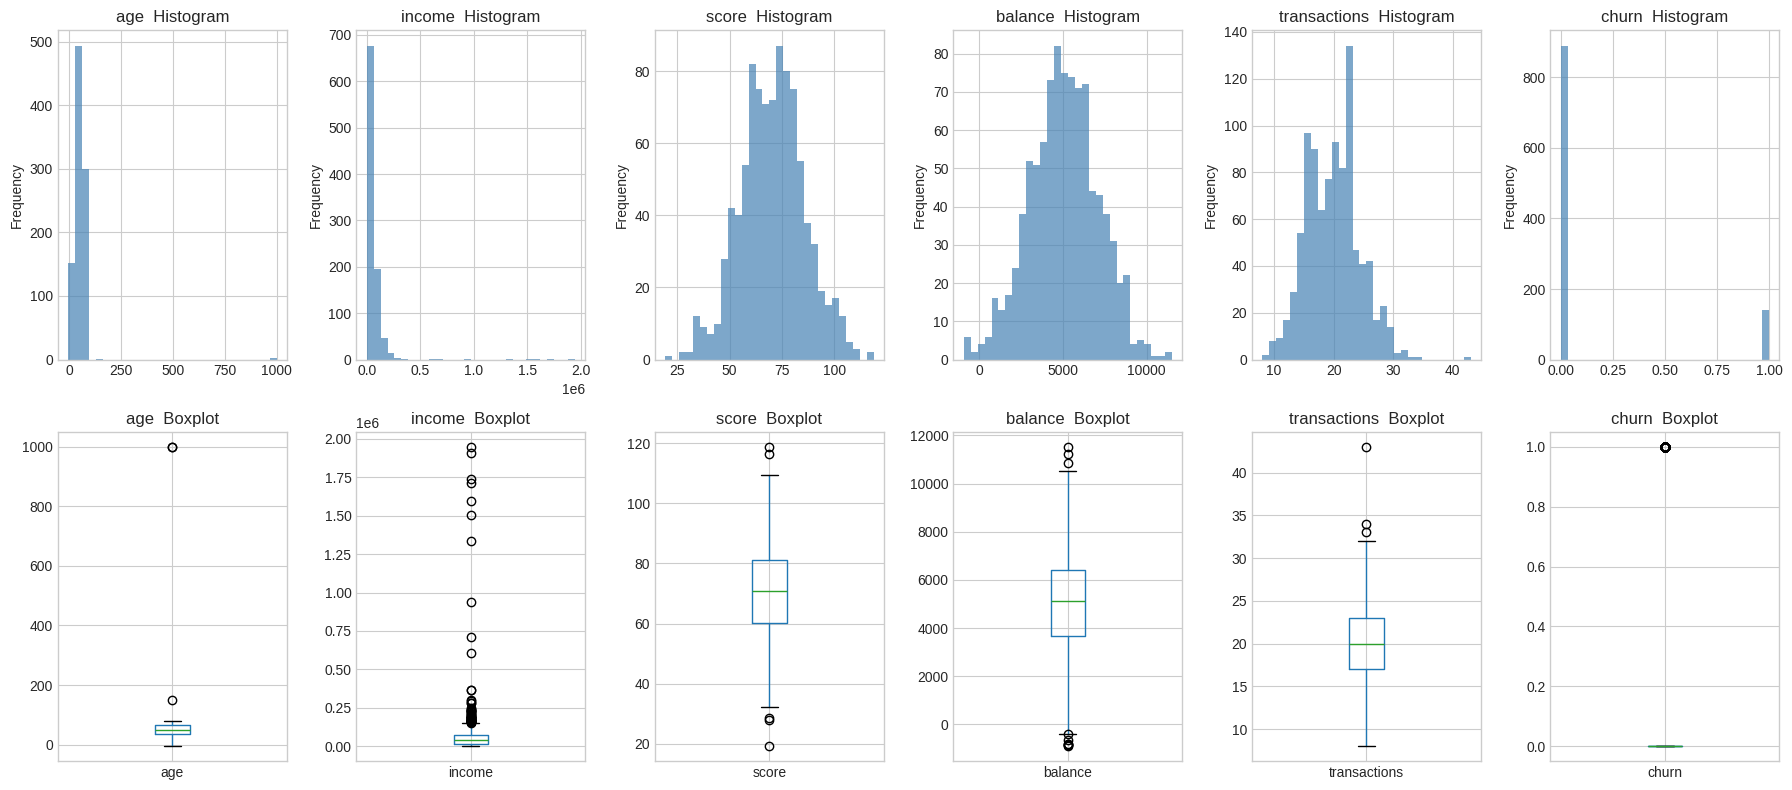

In [7]:
# Numeric distributions
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(2, len(num_cols), figsize=(18,8))
for i, col in enumerate(num_cols):
    df_raw[col].dropna().plot(kind='hist', bins=30, ax=axes[0,i], color='steelblue', alpha=0.7)
    axes[0,i].set_title(f'{col}  Histogram')
    df_raw.boxplot(column=col, ax=axes[1,i])
    axes[1,i].set_title(f'{col}  Boxplot')
plt.tight_layout(); plt.show()

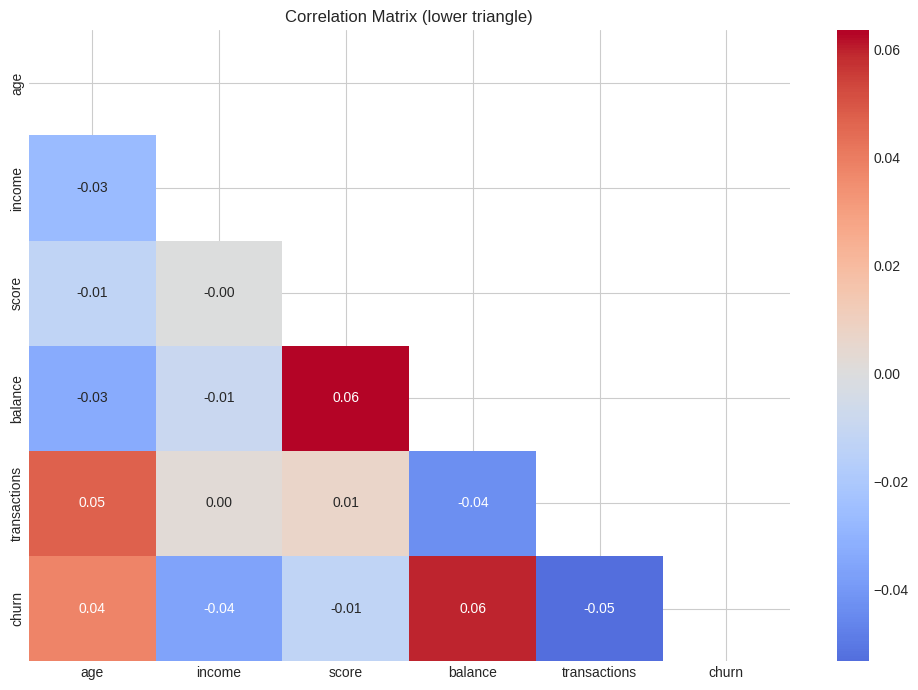

In [8]:
# Correlation matrix
plt.figure(figsize=(10,7))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (lower triangle)')
plt.tight_layout(); plt.show()

## 4. 🔁 Duplicate Detection & Removal

In [9]:
df = df_raw.copy()

print(f'Rows before: {len(df)}')
print(f'Full duplicates: {df.duplicated().sum()}')
print(f'Duplicates (subset, keep=first): {df.duplicated(subset=["age","income","gender","city"], keep="first").sum()}')

# --- Method 1: Drop all exact duplicates ---
df_no_dup = df.drop_duplicates(keep='first')
print(f'\nAfter drop_duplicates: {len(df_no_dup)}')

# --- Method 2: Drop subset duplicates ---
df_sub_dup = df.drop_duplicates(subset=['age','income','city'], keep='last')
print(f'After subset duplicates removal: {len(df_sub_dup)}')

# Use Method 1 going forward
df = df_no_dup.copy().reset_index(drop=True)
print(f'\nWorking dataset: {df.shape}')

Rows before: 1030
Full duplicates: 0
Duplicates (subset, keep=first): 33

After drop_duplicates: 1030
After subset duplicates removal: 992

Working dataset: (1030, 13)


## 5. 🩹 Missing Value Handling  All Techniques

In [10]:
# 
# TECHNIQUE 1: Drop rows / columns
# 
print('T1: Dropping strategies')
print('  Drop any row with NaN:', df.dropna().shape)
print('  Drop rows if ALL NaN:', df.dropna(how='all').shape)
print('  Drop cols > 50% missing:', df.dropna(axis=1, thresh=int(0.5*len(df))).shape)
print('  Drop rows with NaN in key cols:', df.dropna(subset=['age','income']).shape)

T1: Dropping strategies
  Drop any row with NaN: (318, 13)
  Drop rows if ALL NaN: (1030, 13)
  Drop cols > 50% missing: (1030, 13)
  Drop rows with NaN in key cols: (869, 13)


In [11]:
# 
# TECHNIQUE 2: Simple Statistical Imputation
# 
df_imp = df.copy()
num_cols = ['age','income','score','balance','transactions']

# Mean imputation
imp_mean = SimpleImputer(strategy='mean')
df_imp[num_cols] = imp_mean.fit_transform(df_imp[num_cols])

# Median imputation (better for skewed data)
df_med = df.copy()
imp_med = SimpleImputer(strategy='median')
df_med[num_cols] = imp_med.fit_transform(df_med[num_cols])

# Mode imputation (for categoricals)
cat_cols = ['gender','city','education']
imp_mode = SimpleImputer(strategy='most_frequent')
df_imp[cat_cols] = imp_mode.fit_transform(df_imp[cat_cols])

# Constant imputation
imp_const = SimpleImputer(strategy='constant', fill_value=-999)
print('\nT2: Simple imputation complete')
print('Missing after mean+mode imputation:', df_imp[num_cols+cat_cols].isnull().sum().sum())


T2: Simple imputation complete
Missing after mean+mode imputation: 511


In [12]:
# 
# TECHNIQUE 3: KNN Imputation
# 
df_knn = df[num_cols].copy()
knn_imp = KNNImputer(n_neighbors=5, weights='uniform')
df_knn_imputed = pd.DataFrame(knn_imp.fit_transform(df_knn), columns=num_cols)
print('T3: KNN Imputation  missing after:', df_knn_imputed.isnull().sum().sum())

T3: KNN Imputation  missing after: 0


In [13]:
# 
# TECHNIQUE 4: Iterative / MICE Imputation
# 
df_mice = df[num_cols].copy()
mice_imp = IterativeImputer(max_iter=10, random_state=RANDOM_STATE, initial_strategy='mean')
df_mice_imputed = pd.DataFrame(mice_imp.fit_transform(df_mice), columns=num_cols)
print('T4: MICE Imputation  missing after:', df_mice_imputed.isnull().sum().sum())

T4: MICE Imputation  missing after: 0


In [14]:
# 
# TECHNIQUE 5: Missingness Indicator (add flag + impute)
# 
df_ind = df.copy()
for col in num_cols:
    df_ind[f'{col}_missing'] = df_ind[col].isnull().astype(int)
df_ind[num_cols] = imp_mean.transform(df_ind[num_cols])
print('T5: Missingness Indicator  new flag columns added:')
print([c for c in df_ind.columns if 'missing' in c])

T5: Missingness Indicator  new flag columns added:
['age_missing', 'income_missing', 'score_missing', 'balance_missing', 'transactions_missing']


In [15]:
# 
# TECHNIQUE 6: Forward Fill / Backward Fill (for time-series)
# 
df_ts = df.sort_values('signup_date').copy()
df_ffill = df_ts.copy()
df_ffill[num_cols] = df_ffill[num_cols].ffill()
df_bfill = df_ts.copy()
df_bfill[num_cols] = df_bfill[num_cols].bfill()
print('T6: ffill/bfill applied (useful for time-series data)')
print('  ffill remaining NaN:', df_ffill[num_cols].isnull().sum().sum())

# 
# TECHNIQUE 7: Interpolation
# 
df_interp = df_ts[num_cols].copy()
df_interp_linear = df_interp.interpolate(method='linear')
df_interp_spline = df_interp.interpolate(method='polynomial', order=2)
print('T7: Interpolation methods applied')

#  Final clean version for next sections 
df = df_imp.copy()  # using mean+mode imputed

T6: ffill/bfill applied (useful for time-series data)
  ffill remaining NaN: 0
T7: Interpolation methods applied


## 6. 🎯 Outlier Detection & Treatment

In [16]:
from scipy import stats

# 
# METHOD 1: Z-Score
# 
z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_z = (z_scores > 3).any(axis=1)
print(f'Z-Score outliers (|z|>3): {outliers_z.sum()}')

# 
# METHOD 2: IQR (Interquartile Range)
# 
def iqr_outliers(df, col, factor=1.5):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor*IQR, Q3 + factor*IQR
    return (df[col] < lower) | (df[col] > upper), lower, upper

for col in ['income','age','score']:
    mask, lo, hi = iqr_outliers(df, col)
    print(f'  IQR outliers in {col}: {mask.sum()} (bounds: [{lo:.1f}, {hi:.1f}])')

Z-Score outliers (|z|>3): 23
  IQR outliers in income: 66 (bounds: [-54712.9, 142105.8])
  IQR outliers in age: 3 (bounds: [-7.5, 108.5])
  IQR outliers in score: 18 (bounds: [33.7, 107.4])


In [17]:
# 
# METHOD 3: Isolation Forest
# 
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
pred_iso = iso.fit_predict(df[num_cols])
print(f'Isolation Forest outliers: {(pred_iso==-1).sum()}')

# 
# METHOD 4: Local Outlier Factor
# 
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred_lof = lof.fit_predict(df[num_cols])
print(f'LOF outliers: {(pred_lof==-1).sum()}')

# 
# METHOD 5: Elliptic Envelope (assumes Gaussian)
# 
ee = EllipticEnvelope(contamination=0.05, random_state=RANDOM_STATE)
pred_ee = ee.fit_predict(df[num_cols])
print(f'Elliptic Envelope outliers: {(pred_ee==-1).sum()}')

Isolation Forest outliers: 52
LOF outliers: 52
Elliptic Envelope outliers: 53


After outlier removal: (978, 13)
After winsorizing (1%-99%):                   min         max
age           18.0000     79.0000
income       400.0183 367196.8344
score         33.7995    105.4195
balance      327.3422   9514.3658
transactions  11.0000     30.0000


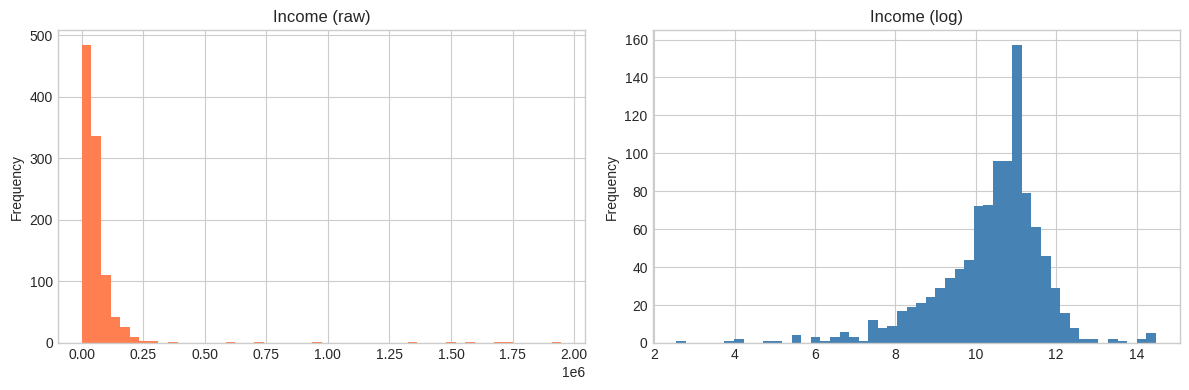

In [18]:
# 
# TREATMENT 1: Removal
# 
df_no_out = df[pred_iso == 1].copy().reset_index(drop=True)
print(f'After outlier removal: {df_no_out.shape}')

# 
# TREATMENT 2: Capping / Winsorizing
# 
df_cap = df.copy()
for col in num_cols:
    lo, hi = df_cap[col].quantile(0.01), df_cap[col].quantile(0.99)
    df_cap[col] = df_cap[col].clip(lower=lo, upper=hi)
print('After winsorizing (1%-99%):', df_cap[num_cols].describe().T[['min','max']])

# 
# TREATMENT 3: Log Transform (squish skewed data)
# 
df_log = df.copy()
df_log['income_log'] = np.log1p(df_log['income'])
df_log['transactions_log'] = np.log1p(df_log['transactions'])

fig, axes = plt.subplots(1,2,figsize=(12,4))
df['income'].plot(kind='hist', bins=50, ax=axes[0], color='coral', title='Income (raw)')
df_log['income_log'].plot(kind='hist', bins=50, ax=axes[1], color='steelblue', title='Income (log)')
plt.tight_layout(); plt.show()

df = df_cap.copy()  # Use capped version

## 7. 🔄 Data Type Conversion

In [19]:
print('Before:\n', df.dtypes, '\n')

# Numeric casting
df['age']          = df['age'].astype(np.int32)
df['transactions'] = df['transactions'].astype(np.int32)
df['churn']        = df['churn'].astype(np.int8)

# Categorical dtype (memory efficient)
for col in ['gender','city','product','education']:
    df[col] = df[col].astype('category')

# Boolean
df['is_churned'] = df['churn'].astype(bool)

# Datetime (ensure proper type)
df['signup_date'] = pd.to_datetime(df['signup_date'])

print('After:\n', df.dtypes)
print(f'\nMemory usage before: {df_raw.memory_usage(deep=True).sum()/1e6:.2f} MB')
print(f'Memory usage after:  {df.memory_usage(deep=True).sum()/1e6:.2f} MB')

Before:
 age                    float64
income                 float64
score                  float64
balance                float64
transactions           float64
gender                  object
city                    object
product                 object
education               object
signup_date     datetime64[ns]
churn                    int64
name                    object
email                   object
dtype: object 

After:
 age                      int32
income                 float64
score                  float64
balance                float64
transactions             int32
gender                category
city                  category
product               category
education             category
signup_date     datetime64[ns]
churn                     int8
name                    object
email                   object
is_churned                bool
dtype: object

Memory usage before: 0.37 MB
Memory usage after:  0.16 MB


## 8. ✍️ String & Text Cleaning

In [20]:
import re

#  Gender standardization 
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
gender_map = {
    'male':'Male','m':'Male','female':'Female','f':'Female',
    'fem':'Female','man':'Male','woman':'Female','none':'Unknown'
}
df['gender'] = df['gender'].map(gender_map).fillna('Unknown')
print('Gender value counts:\n', df['gender'].value_counts())

#  Email cleaning 
email_pattern = r'^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$'
df['email_clean'] = df['email'].astype(str).str.strip().str.lower()
df['email_valid'] = df['email_clean'].apply(lambda x: bool(re.match(email_pattern, x)))
print(f'\nValid emails: {df["email_valid"].sum()} / {len(df)}')

#  Name cleaning 
df['name_clean'] = (
    df['name']
    .str.strip()                        # remove leading/trailing spaces
    .str.replace(r'[^\w\s]', '', regex=True)  # remove special chars
    .str.replace(r'\s+', ' ', regex=True)     # collapse spaces
    .str.title()                        # title case
)

#  Extract numeric from string 
sample = pd.Series(['$1,200.50', '€3000', '2500.0 USD', 'N/A'])
extracted = sample.str.extract(r'([\d,\.]+)')[0].str.replace(',','').astype(float)
print('\nExtracted numbers:', extracted.tolist())

Gender value counts:
 gender
Female     457
Male       441
Unknown    132
Name: count, dtype: int64

Valid emails: 434 / 1030

Extracted numbers: [1200.5, 3000.0, 2500.0, nan]


## 9. ⚙️ Feature Engineering

In [21]:
df_fe = df.copy()

#  Interaction features 
df_fe['income_per_age']       = df_fe['income'] / (df_fe['age'] + 1)
df_fe['balance_score_ratio']  = df_fe['balance'] / (df_fe['score'] + 1)
df_fe['income_x_score']       = df_fe['income'] * df_fe['score']

#  Polynomial features 
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_feats = poly.fit_transform(df_fe[['income','age','score']])
poly_names = poly.get_feature_names_out(['income','age','score'])
df_poly = pd.DataFrame(poly_feats, columns=poly_names)
print('Polynomial features:', df_poly.columns.tolist())

#  Binning / Discretization 
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0,25,35,50,65,100],
                             labels=['Youth','Young','Middle','Senior','Elder'])

df_fe['income_quantile'] = pd.qcut(df_fe['income'], q=4,
                                    labels=['Q1','Q2','Q3','Q4'])

#  Log & sqrt transforms 
df_fe['log_income']       = np.log1p(df_fe['income'])
df_fe['sqrt_transactions'] = np.sqrt(df_fe['transactions'])
df_fe['income_squared']   = df_fe['income'] ** 2

#  Aggregation features 
city_agg = df_fe.groupby('city', observed=True)['income'].agg(['mean','std','max']).reset_index()
city_agg.columns = ['city','city_mean_income','city_std_income','city_max_income']
df_fe = df_fe.merge(city_agg, on='city', how='left')

print('\nFeature-engineered shape:', df_fe.shape)

Polynomial features: ['income', 'age', 'score', 'income^2', 'income age', 'income score', 'age^2', 'age score', 'score^2']

Feature-engineered shape: (1030, 28)


## 10. 📅 Date & Time Feature Extraction

In [22]:
df_fe['year']            = df_fe['signup_date'].dt.year
df_fe['month']           = df_fe['signup_date'].dt.month
df_fe['day']             = df_fe['signup_date'].dt.day
df_fe['dayofweek']       = df_fe['signup_date'].dt.dayofweek   # 0=Mon
df_fe['quarter']         = df_fe['signup_date'].dt.quarter
df_fe['is_weekend']      = df_fe['dayofweek'].isin([5,6]).astype(int)
df_fe['days_since_signup'] = (pd.Timestamp.today() - df_fe['signup_date']).dt.days

# Cyclical encoding (sin/cos) for periodic features
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)
df_fe['dow_sin']   = np.sin(2 * np.pi * df_fe['dayofweek'] / 7)
df_fe['dow_cos']   = np.cos(2 * np.pi * df_fe['dayofweek'] / 7)

print('Date features added:', ['year','month','day','dayofweek','quarter',
                                 'is_weekend','days_since_signup',
                                 'month_sin','month_cos','dow_sin','dow_cos'])

Date features added: ['year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'days_since_signup', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


## 11. 🏷️ Encoding Categorical Variables

In [23]:
df_enc = df_fe.copy()

#  Label Encoding 
le = LabelEncoder()
df_enc['city_label'] = le.fit_transform(df_enc['city'].astype(str))
print('Label encoded city:', dict(zip(le.classes_, le.transform(le.classes_))))

#  Ordinal Encoding 
edu_order = [['High School','Bachelor','Master','PhD']]
oe = OrdinalEncoder(categories=edu_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_enc['edu_ordinal'] = oe.fit_transform(df_enc[['education']].astype(str))
print('\nOrdinal education mapping:', dict(zip(edu_order[0], range(len(edu_order[0])))))

#  One-Hot Encoding 
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
gender_ohe = ohe.fit_transform(df_enc[['gender']])
gender_cols = ohe.get_feature_names_out(['gender'])
df_enc[gender_cols] = gender_ohe
print('\nOHE gender columns:', gender_cols.tolist())

# pd.get_dummies alternative
df_dummies = pd.get_dummies(df_enc, columns=['product'], prefix='prod', drop_first=True)
print('After get_dummies shape:', df_dummies.shape)

#  Target / Mean Encoding 
target_enc = df_enc.groupby('city', observed=True)['churn'].mean()
df_enc['city_target_enc'] = df_enc['city'].map(target_enc)
print('\nTarget encoded city (mean churn):\n', target_enc.head())

#  Frequency / Count Encoding 
freq_enc = df_enc['city'].value_counts(normalize=True)
df_enc['city_freq_enc'] = df_enc['city'].map(freq_enc)
print('\nFrequency encoded city sample:\n', df_enc['city_freq_enc'].head())

#  Binary Encoding 
try:
    import category_encoders as ce
    be = ce.BinaryEncoder(cols=['city'])
    df_binary = be.fit_transform(df_enc)
    print('\nBinary encoding done (category_encoders)')
except ImportError:
    print('\n  category_encoders not installed (pip install category_encoders)')

Label encoded city: {'Alex': np.int64(0), 'Aswan': np.int64(1), 'Cairo': np.int64(2), 'Giza': np.int64(3), 'Luxor': np.int64(4), np.str_('nan'): np.int64(5)}

Ordinal education mapping: {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}

OHE gender columns: ['gender_Male', 'gender_Unknown']
After get_dummies shape: (1030, 45)

Target encoded city (mean churn):
 city
Alex    0.1258
Aswan   0.1510
Cairo   0.1471
Giza    0.1307
Luxor   0.1370
Name: churn, dtype: float64

Frequency encoded city sample:
 0   0.2326
1   0.2189
2   0.1813
3   0.2007
4   0.2007
Name: city_freq_enc, dtype: category
Categories (5, float64): [0.1813, 0.2189, 0.2326, 0.2007, 0.1665]

Binary encoding done (category_encoders)


## 12. 📏 Feature Scaling & Normalization

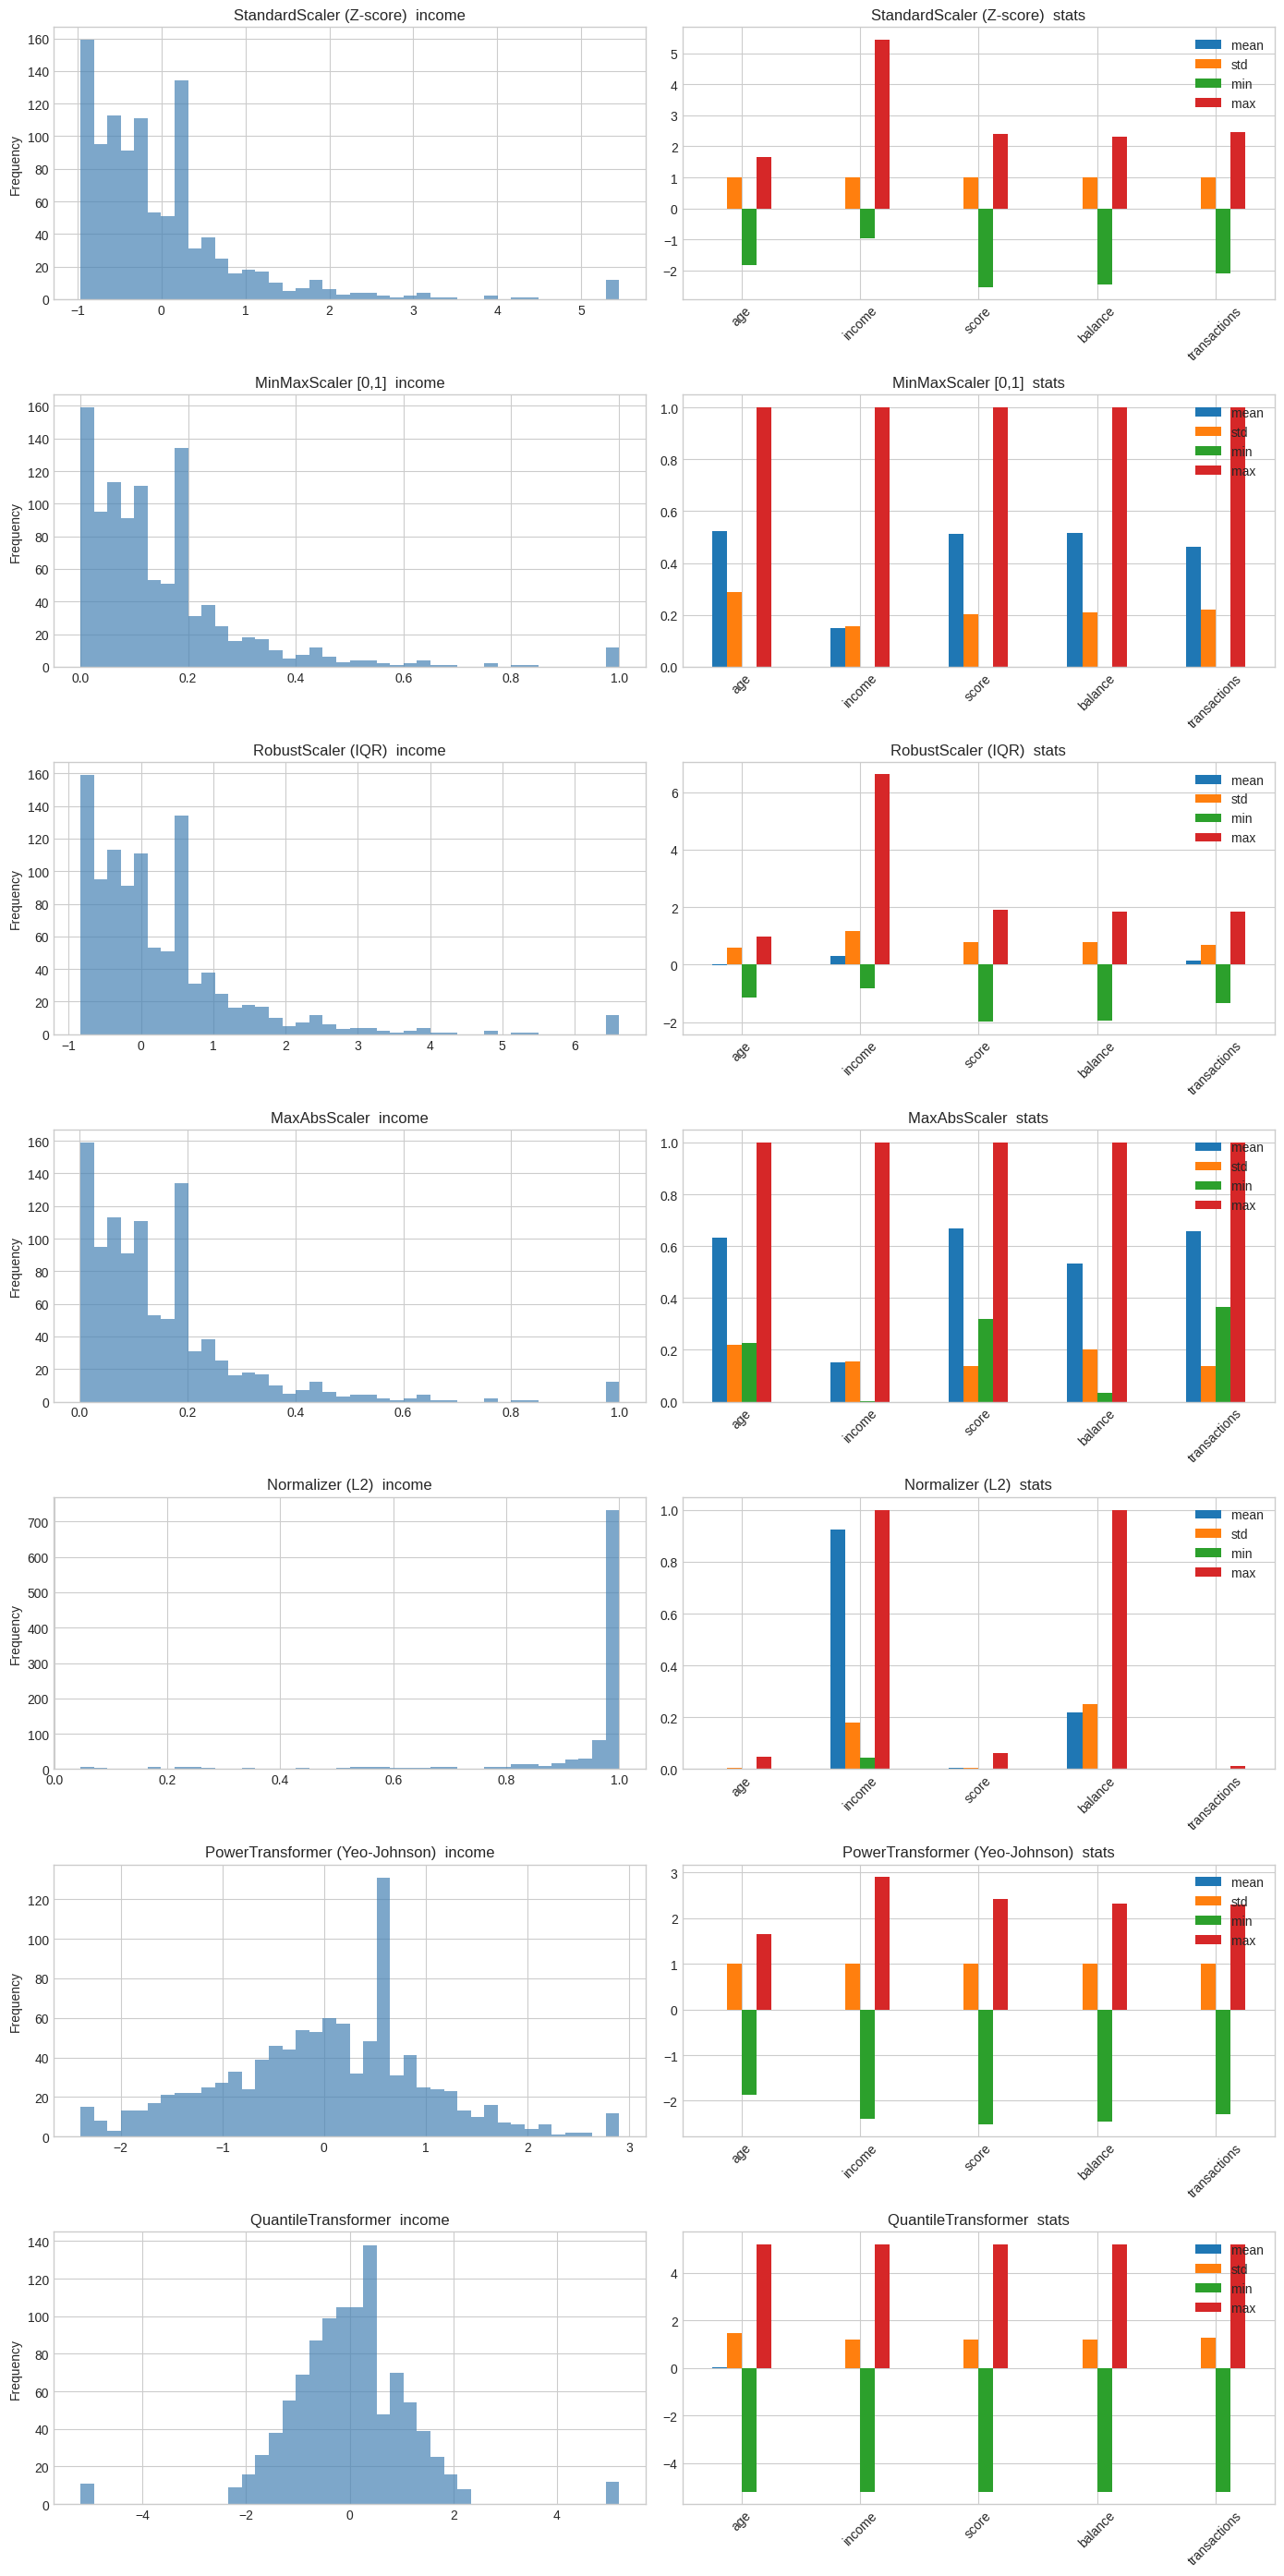

In [24]:
scale_cols = ['age','income','score','balance','transactions']
df_scale = df[scale_cols].copy()

scalers = {
    'StandardScaler (Z-score)':  StandardScaler(),
    'MinMaxScaler [0,1]':         MinMaxScaler(),
    'RobustScaler (IQR)':         RobustScaler(),
    'MaxAbsScaler':               MaxAbsScaler(),
    'Normalizer (L2)':            Normalizer(),
    'PowerTransformer (Yeo-Johnson)': PowerTransformer(method='yeo-johnson'),
    'QuantileTransformer':        QuantileTransformer(output_distribution='normal', random_state=RANDOM_STATE),
}

fig, axes = plt.subplots(len(scalers), 2, figsize=(14, 4*len(scalers)))
for i, (name, scaler) in enumerate(scalers.items()):
    scaled = scaler.fit_transform(df_scale)
    df_s = pd.DataFrame(scaled, columns=scale_cols)
    df_s['income'].plot(kind='hist', bins=40, ax=axes[i,0], color='steelblue', alpha=0.7)
    axes[i,0].set_title(f'{name}  income')
    df_s.describe().T[['mean','std','min','max']].plot(kind='bar', ax=axes[i,1], rot=45)
    axes[i,1].set_title(f'{name}  stats')

plt.tight_layout(); plt.show()

## 13. ⚖️ Handling Imbalanced Data

In [25]:
# Prepare numeric X, y
feat_cols = ['age','income','score','balance','transactions']
X = df[feat_cols].values
y = df['churn'].values

print(f'Class distribution: {np.bincount(y)}')
print(f'Imbalance ratio: 1:{np.bincount(y)[0]/np.bincount(y)[1]:.1f}')

if IMBLEARN:
    techniques = [
        ('SMOTE',              SMOTE(random_state=RANDOM_STATE)),
        ('ADASYN',             ADASYN(random_state=RANDOM_STATE)),
        ('RandomOverSampler',  RandomOverSampler(random_state=RANDOM_STATE)),
        ('RandomUnderSampler', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('TomekLinks',         TomekLinks()),
        ('SMOTETomek',         SMOTETomek(random_state=RANDOM_STATE)),
        ('SMOTEENN',           SMOTEENN(random_state=RANDOM_STATE)),
    ]
    results = []
    for name, sampler in techniques:
        try:
            Xr, yr = sampler.fit_resample(X, y)
            counts = np.bincount(yr)
            results.append({'Technique': name, 'Class 0': counts[0], 'Class 1': counts[1], 'Total': len(yr)})
        except Exception as e:
            results.append({'Technique': name, 'Class 0': 'Error', 'Class 1': str(e), 'Total': '-'})

    print('\nResampling Results:')
    display(pd.DataFrame(results))
else:
    print('\n⚠️  Install imbalanced-learn: pip install imbalanced-learn')

#  Class weights alternative 
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y), y=y)
print(f'\nBalanced class weights: {{0: {cw[0]:.3f}, 1: {cw[1]:.3f}}}')

Class distribution: [889 141]
Imbalance ratio: 1:6.3

Resampling Results:


,Technique,Class 0,Class 1,Total
0,SMOTE,889,889,1778
1,ADASYN,889,866,1755
2,RandomOverSampler,889,889,1778
3,RandomUnderSampler,141,141,282
4,TomekLinks,828,141,969
5,SMOTETomek,779,779,1558
6,SMOTEENN,408,491,899



Balanced class weights: {0: 0.579, 1: 3.652}


## 14. 🎯 Feature Selection

Variance Threshold: 5 → 5 features
SelectKBest (k=4): ['income', 'score', 'balance', 'transactions']

Mutual Information Scores:
income         0.0084
balance        0.0072
age            0.0000
score          0.0000
transactions   0.0000
dtype: float64

RFE selected: ['income', 'score', 'balance']

RF Feature Importances:
balance        0.2433
income         0.2407
score          0.2147
age            0.1701
transactions   0.1313
dtype: float64


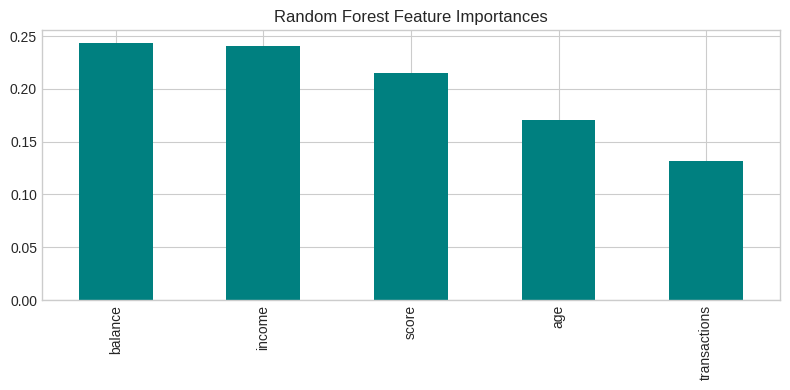

In [26]:
from sklearn.ensemble import RandomForestClassifier

X_sel = df[feat_cols].values
y_sel = df['churn'].values

#  Variance Threshold 
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_sel)
print(f'Variance Threshold: {X_sel.shape[1]} → {X_vt.shape[1]} features')

#  SelectKBest (ANOVA F) 
skb = SelectKBest(f_classif, k=4)
X_skb = skb.fit_transform(X_sel, y_sel)
sel_mask = skb.get_support()
print(f'SelectKBest (k=4): {np.array(feat_cols)[sel_mask].tolist()}')

#  Mutual Information 
mi_scores = mutual_info_classif(X_sel, y_sel, random_state=RANDOM_STATE)
mi_df = pd.Series(mi_scores, index=feat_cols).sort_values(ascending=False)
print(f'\nMutual Information Scores:\n{mi_df}')

#  RFE (Recursive Feature Elimination) 
rf = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)
rfe = RFE(estimator=rf, n_features_to_select=3)
rfe.fit(X_sel, y_sel)
print(f'\nRFE selected: {np.array(feat_cols)[rfe.support_].tolist()}')

#  Feature Importances 
rf.fit(X_sel, y_sel)
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print(f'\nRF Feature Importances:\n{importances}')

importances.plot(kind='bar', color='teal', figsize=(8,4))
plt.title('Random Forest Feature Importances')
plt.tight_layout(); plt.show()

## 15. 📉 Dimensionality Reduction

PCA: 5 components explain 95% variance


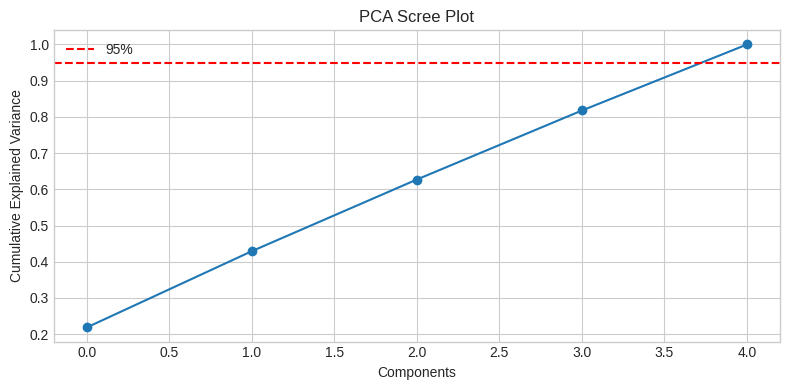

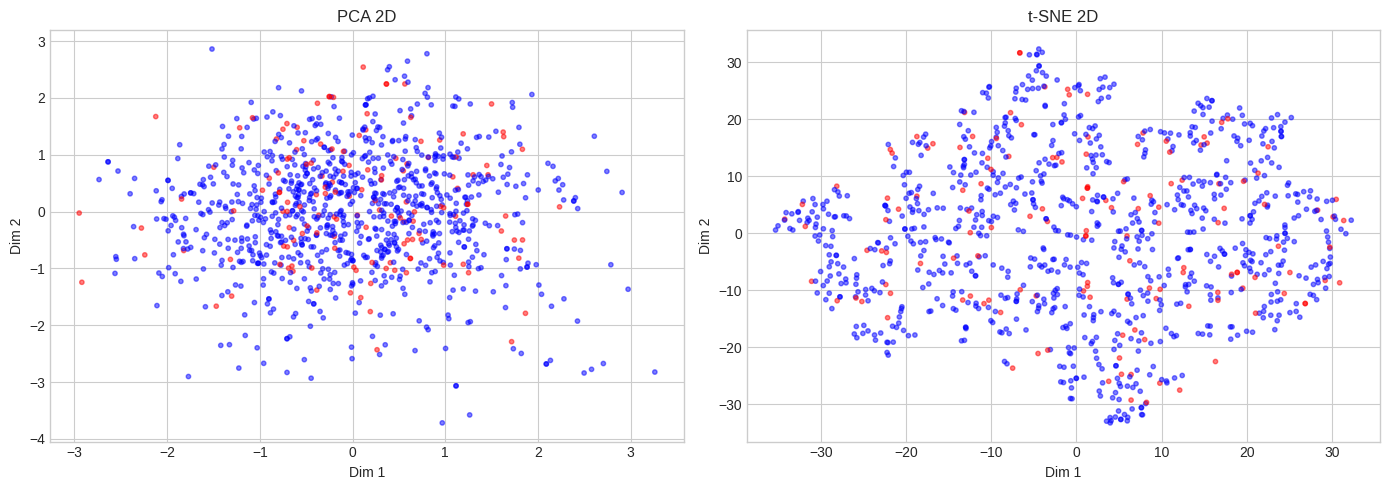

ICA output shape: (1030, 3)


In [27]:
X_sc = StandardScaler().fit_transform(X_sel)

#  PCA 
pca = PCA(n_components=None, random_state=RANDOM_STATE)
pca.fit(X_sc)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f'PCA: {n_95} components explain 95% variance')

plt.figure(figsize=(8,4))
plt.plot(cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.xlabel('Components'); plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot'); plt.legend(); plt.tight_layout(); plt.show()

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_sc)

#  t-SNE 
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_iter=500)
X_tsne = tsne.fit_transform(X_sc)

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, X_emb, title in zip(axes, [X_pca2, X_tsne], ['PCA 2D', 't-SNE 2D']):
    ax.scatter(X_emb[:,0], X_emb[:,1], c=y_sel, cmap='bwr', alpha=0.5, s=10)
    ax.set_title(title); ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
plt.tight_layout(); plt.show()

#  ICA 
ica = FastICA(n_components=3, random_state=RANDOM_STATE)
X_ica = ica.fit_transform(X_sc)
print(f'ICA output shape: {X_ica.shape}')

## 16. 🏗️ Full Preprocessing Pipeline

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df_final = df.copy()
df_final['education'] = df_final['education'].astype(str)
df_final['gender']    = df_final['gender'].astype(str)
df_final['city']      = df_final['city'].astype(str)

num_features = ['age', 'income', 'score', 'balance', 'transactions']
cat_features = ['gender', 'city', 'education', 'product']

X_all = df_final[num_features + cat_features]
y_all = df_final['churn'].values

# Numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combined
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
], remainder='drop')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

# Fit on train, transform both
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f'Train shape: {X_train_prep.shape}')
print(f'Test shape:  {X_test_prep.shape}')
print('\n✅ Pipeline complete  data is model-ready!')

Train shape: (824, 23)
Test shape:  (206, 23)

✅ Pipeline complete  data is model-ready!


##  Summary Cheatsheet

| Technique | When to Use | Key Class/Function |
|---|---|---|
| Drop duplicates | Exact/near-duplicate rows | `df.drop_duplicates()` |
| Mean/Median Impute | MCAR, small % missing | `SimpleImputer` |
| KNN Impute | MAR, moderate % missing | `KNNImputer` |
| MICE/Iterative | Complex patterns | `IterativeImputer` |
| Z-Score outliers | Normally distributed | `scipy.stats.zscore` |
| IQR outliers | Skewed data | Manual IQR calc |
| Isolation Forest | High-dimensional | `IsolationForest` |
| Winsorizing | Keep rows, fix extremes | `.clip()` |
| Label Encoding | Ordinal, binary | `LabelEncoder` |
| One-Hot Encoding | Nominal, few levels | `OneHotEncoder` |
| Target Encoding | High cardinality | Group mean |
| Standard Scaling | Gaussian, SVM/LR | `StandardScaler` |
| MinMax Scaling | Neural Networks | `MinMaxScaler` |
| Robust Scaling | Outliers present | `RobustScaler` |
| SMOTE | Imbalanced binary | `SMOTE` |
| PCA | Correlated features | `PCA` |
| RFE | Tree/linear models | `RFE` |
